# 3D Linear Precision Fix: DEC p_ij Dual Face Construction

This notebook documents the fix for 3D barycentric dual area vectors
that restores **machine-precision linear precision** on arbitrary
tetrahedral meshes.

## The problem

The DDG integrated gradient operator:

$$Df_i = \tfrac{1}{2} \sum_{j} (f_j - f_i)\, \mathbf{A}_{ij}$$

should satisfy the **linear precision identity**:

$$\tfrac{1}{2} \sum_{j} \mathbf{d}_{ij} \otimes \mathbf{A}_{ij} = \text{Vol}_i \cdot \mathbf{I}$$

In 2D this held for both barycentric and circumcentric duals. In 3D,
the old `e_star` fan-walk produced area vectors with a **~14% relative error**
in the off-diagonal components of this tensor.

## The fix

The dual face polygon must interleave **tet barycenters** with **face barycenters**
$\tfrac{1}{3}(\mathbf{x}_i + \mathbf{x}_j + \mathbf{x}_k)$ — the barycenters of
the primal triangular faces shared by consecutive tetrahedra around the edge.
This is the standard DEC p_ij dual cell construction.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

from hyperct import Complex
from hyperct.ddg import compute_vd
from hyperct.ddg._dual_cell import dual_cell_faces_3d

from ddgclib.operators.stress import (
    dual_area_vector,
    _dual_area_vector_3d_e_star,
    _dual_area_vector_3d_p_ij,
    scalar_gradient_integrated,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 11

/home/stefan_endres/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/claude/matplotlib-mgt6tlb0 because there was an issue with the default path (/home/stefan_endres/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
def make_mesh_3d(n_refine=1, method='barycentric'):
    HC = Complex(3, domain=[(0.0, 1.0)]*3)
    HC.triangulate()
    for _ in range(n_refine):
        HC.refine_all()
    bV = set()
    for v in HC.V:
        on_bnd = any(abs(v.x_a[d]) < 1e-14 or abs(v.x_a[d]-1.0) < 1e-14
                     for d in range(3))
        v.boundary = on_bnd
        if on_bnd: bV.add(v)
    compute_vd(HC, method=method, cdist=1e-10)
    interior = [v for v in HC.V if v not in bV]
    return HC, bV, interior

## 1. Visualising the two face constructions

For a single interior vertex we draw:
- **Left**: Legacy faces (tet barycenters only — non-planar polygons)
- **Right**: p_ij faces (interleaved face barycenters — finer, more planar sub-triangles)

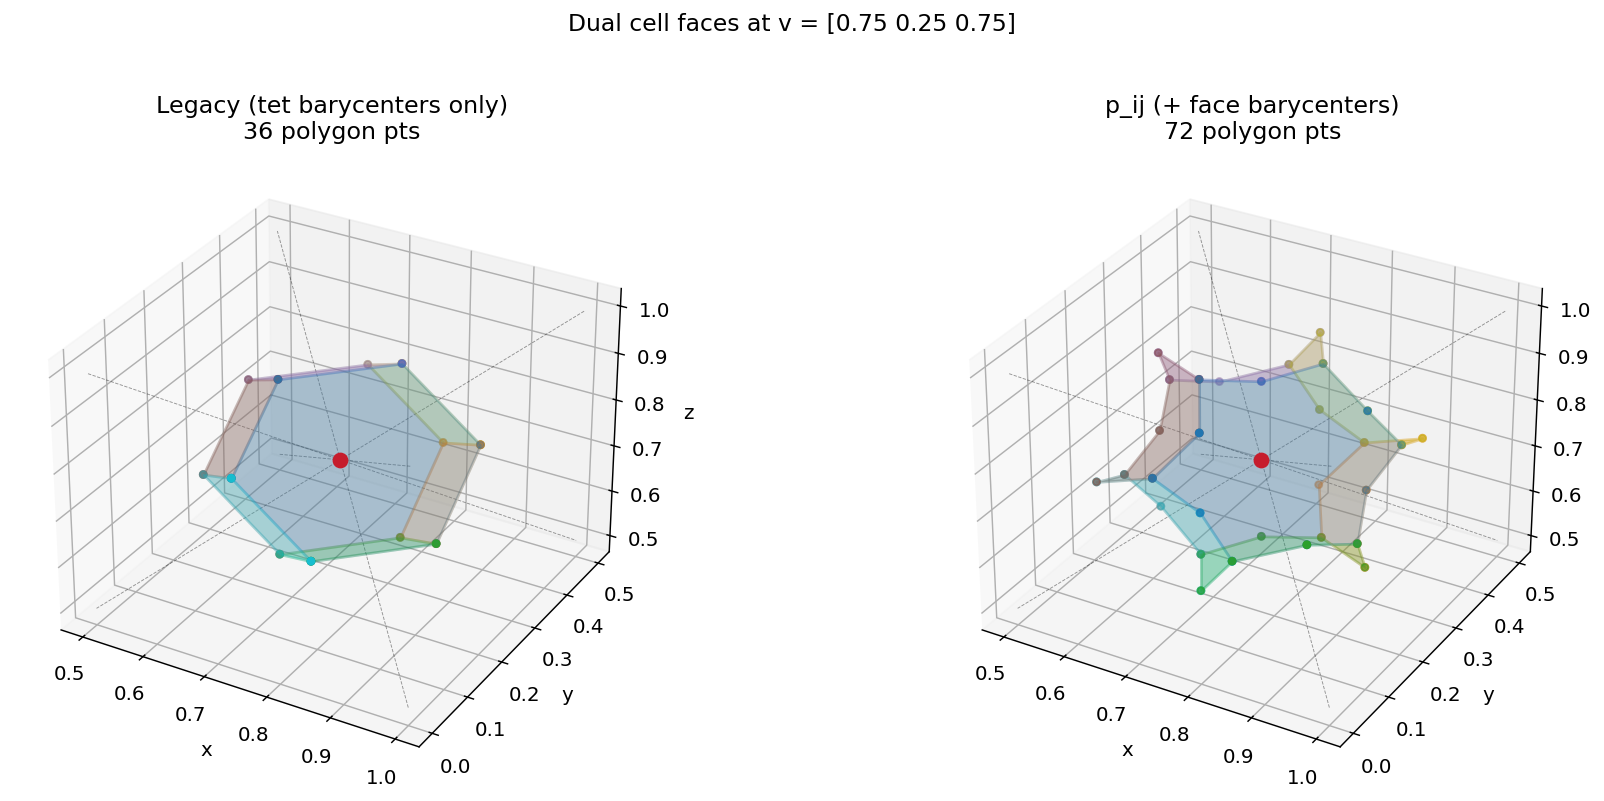

In [3]:
HC, bV, interior = make_mesh_3d(n_refine=1)

# Pick a non-symmetric interior vertex
v0 = [v for v in interior if not np.allclose(v.x_a[:3], [0.5,0.5,0.5])][0]

faces_legacy = dual_cell_faces_3d(v0, HC, include_face_barycenters=False)
faces_p_ij   = dual_cell_faces_3d(v0, HC, include_face_barycenters=True)

fig = plt.figure(figsize=(15, 6))

for col, (faces, title) in enumerate([
    (faces_legacy, f'Legacy (tet barycenters only)\n{sum(len(f) for f in faces_legacy)} polygon pts'),
    (faces_p_ij, f'p_ij (+ face barycenters)\n{sum(len(f) for f in faces_p_ij)} polygon pts'),
]):
    ax = fig.add_subplot(1, 2, col+1, projection='3d')
    colors = plt.cm.tab10(np.linspace(0, 1, len(faces)))

    for idx, face in enumerate(faces):
        poly = [face.tolist()]
        pc = Poly3DCollection(poly, alpha=0.25, facecolor=colors[idx],
                              edgecolor=colors[idx], lw=1.5)
        ax.add_collection3d(pc)
        # Plot face vertices
        ax.scatter(face[:, 0], face[:, 1], face[:, 2],
                   c=[colors[idx]], s=15, zorder=5)

    # Primal vertex and edges
    ax.scatter(*v0.x_a[:3], c='red', s=60, zorder=10)
    for nb in v0.nn:
        ax.plot([v0.x_a[0], nb.x_a[0]], [v0.x_a[1], nb.x_a[1]],
                [v0.x_a[2], nb.x_a[2]], 'k--', lw=0.5, alpha=0.4)

    ax.set_title(title)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

plt.suptitle(f'Dual cell faces at v = {v0.x_a[:3].round(3)}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2. Linear precision identity: before vs after

The tensor $T = \tfrac{1}{2}\sum_j \mathbf{d}_{ij} \otimes \mathbf{A}_{ij}$ should equal $\text{Vol}_i \cdot \mathbf{I}$.

We measure `max |off-diagonal|` across all interior vertices.

In [4]:
print(f'{"Refine":<8} {"n_int":<8} '
      f'{"Legacy max|off|":<20} {"Legacy rel":<16} '
      f'{"p_ij max|off|":<20} {"p_ij rel":<16}')
print('='*92)

for n_ref in [0, 1, 2]:
    HC, bV, interior = make_mesh_3d(n_refine=n_ref)

    max_off_legacy = max_off_pij = 0.0
    max_rel_legacy = max_rel_pij = 0.0

    for v in interior:
        T_leg = np.zeros((3, 3))
        T_pij = np.zeros((3, 3))
        for nb in v.nn:
            d = nb.x_a[:3] - v.x_a[:3]
            T_leg += 0.5 * np.outer(d, _dual_area_vector_3d_e_star(v, nb, HC))
            T_pij += 0.5 * np.outer(d, _dual_area_vector_3d_p_ij(v, nb, HC))

        for T, stats in [(T_leg, 'legacy'), (T_pij, 'pij')]:
            diag = np.diag(T)
            off = np.max(np.abs(T - np.diag(diag)))
            vol = abs(diag.mean())
            rel = off / vol if vol > 1e-30 else 0
            if stats == 'legacy':
                max_off_legacy = max(max_off_legacy, off)
                max_rel_legacy = max(max_rel_legacy, rel)
            else:
                max_off_pij = max(max_off_pij, off)
                max_rel_pij = max(max_rel_pij, rel)

    print(f'{n_ref:<8} {len(interior):<8} '
          f'{max_off_legacy:<20.6e} {max_rel_legacy:<16.6e} '
          f'{max_off_pij:<20.6e} {max_rel_pij:<16.6e}')

Refine   n_int    Legacy max|off|      Legacy rel       p_ij max|off|        p_ij rel        
0        1        3.125000e-02         1.428571e-01     1.387779e-17         5.551115e-17    
1        9        3.906250e-03         1.428571e-01     2.602085e-18         8.326673e-17    


2        91       4.882812e-04         1.428571e-01     5.421011e-19         1.110223e-16    


## 3. DDG gradient error: linear field $f = x - 2y + 3z$

Compare legacy vs p_ij against `a * Vol` (the exact integral of a constant gradient).

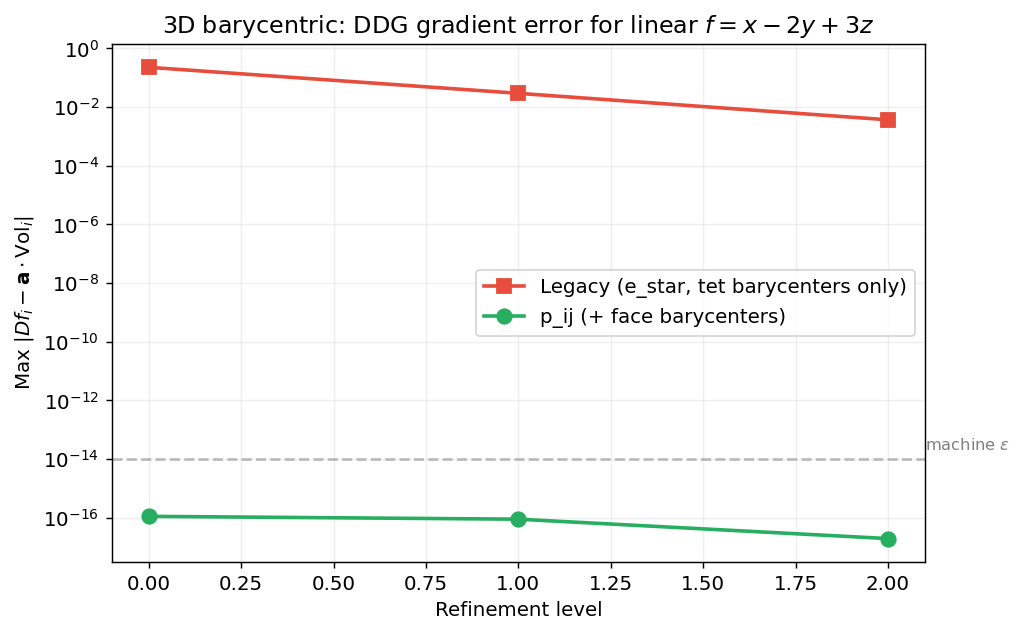

In [5]:
a = np.array([1.0, -2.0, 3.0])
f_lin = lambda x: x[0] - 2*x[1] + 3*x[2]

refines = [0, 1, 2]
err_legacy_list = []
err_pij_list = []

for n_ref in refines:
    HC, bV, interior = make_mesh_3d(n_refine=n_ref)
    for v in HC.V:
        v.f = f_lin(v.x_a[:3])

    max_err_leg = 0.0
    max_err_pij = 0.0
    for v in interior:
        # p_ij volume (correct)
        T = np.zeros((3, 3))
        for nb in v.nn:
            d = nb.x_a[:3] - v.x_a[:3]
            T += 0.5 * np.outer(d, _dual_area_vector_3d_p_ij(v, nb, HC))
        vol = np.diag(T).mean()
        expected = a * vol

        # Legacy
        Df_leg = np.zeros(3)
        for nb in v.nn:
            df = nb.f - v.f
            Df_leg += 0.5 * df * _dual_area_vector_3d_e_star(v, nb, HC)
        max_err_leg = max(max_err_leg, np.linalg.norm(Df_leg - expected))

        # p_ij (new)
        Df_pij = np.zeros(3)
        for nb in v.nn:
            df = nb.f - v.f
            Df_pij += 0.5 * df * _dual_area_vector_3d_p_ij(v, nb, HC)
        max_err_pij = max(max_err_pij, np.linalg.norm(Df_pij - expected))

    err_legacy_list.append(max_err_leg)
    err_pij_list.append(max_err_pij)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(refines, err_legacy_list, 's-', color='#e74c3c', lw=2,
            markersize=8, label='Legacy (e_star, tet barycenters only)')
ax.semilogy(refines, [max(e, 1e-17) for e in err_pij_list], 'o-',
            color='#27ae60', lw=2, markersize=8,
            label='p_ij (+ face barycenters)')
ax.axhline(1e-14, color='gray', ls='--', alpha=0.5)
ax.text(refines[-1]+0.1, 2e-14, 'machine $\\epsilon$', fontsize=9, color='gray')
ax.set_xlabel('Refinement level')
ax.set_ylabel('Max $|Df_i - \\mathbf{a} \\cdot \\mathrm{Vol}_i|$')
ax.set_title('3D barycentric: DDG gradient error for linear $f = x - 2y + 3z$')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 4. Dual face area vectors: per-edge comparison

Show individual $\mathbf{A}_{ij}$ for one vertex — red (legacy) vs green (p_ij).

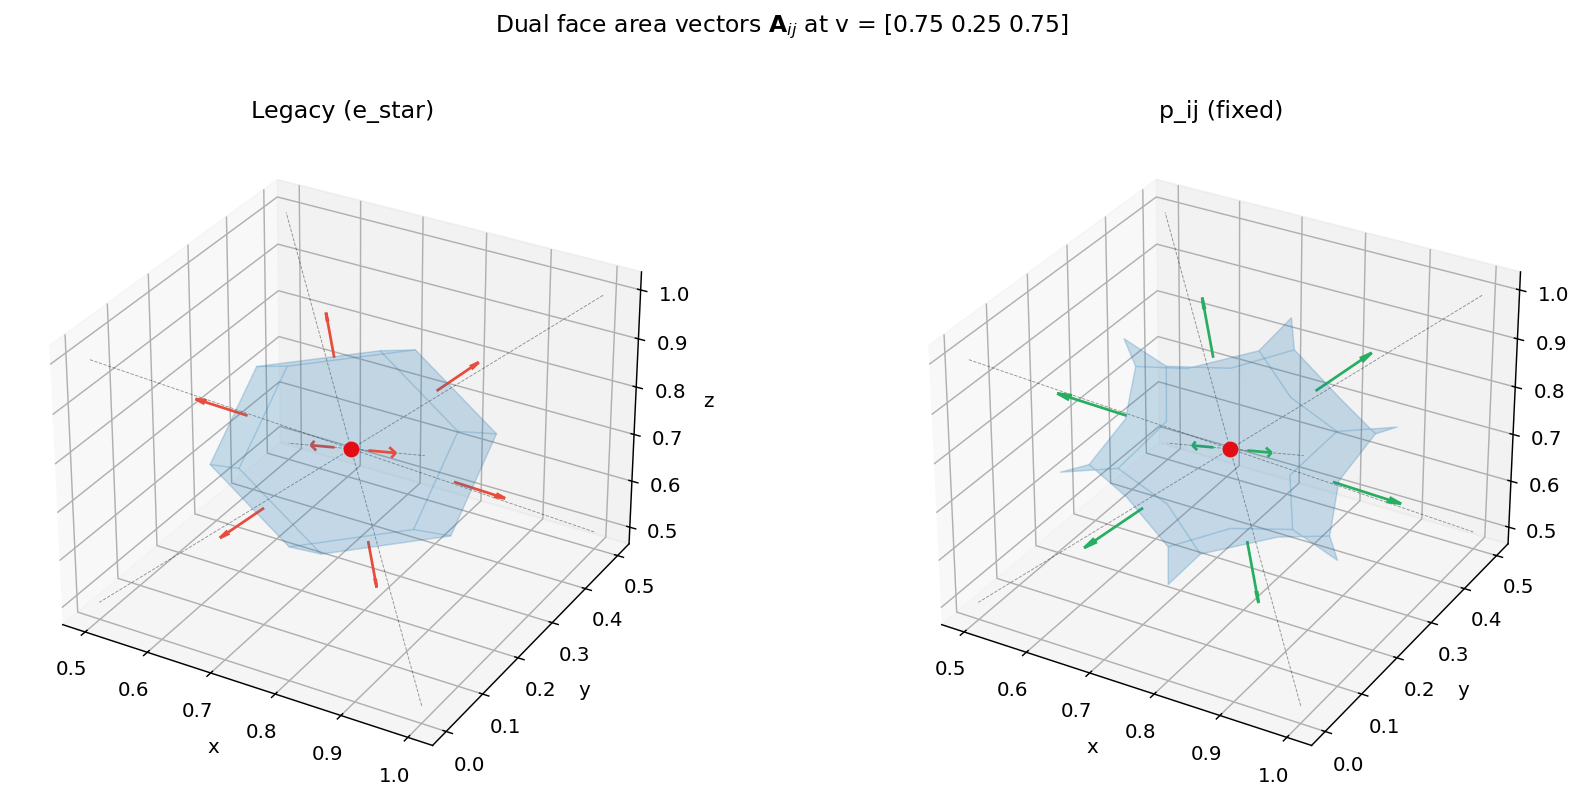

In [6]:
HC, bV, interior = make_mesh_3d(n_refine=1)
v0 = [v for v in interior if not np.allclose(v.x_a[:3], [0.5,0.5,0.5])][0]

fig = plt.figure(figsize=(14, 6))

for col, (area_fn, label, color) in enumerate([
    (_dual_area_vector_3d_e_star, 'Legacy (e_star)', '#e74c3c'),
    (_dual_area_vector_3d_p_ij, 'p_ij (fixed)', '#27ae60'),
]):
    ax = fig.add_subplot(1, 2, col+1, projection='3d')

    # Draw dual cell faces
    faces = dual_cell_faces_3d(v0, HC, include_face_barycenters=(col==1))
    for face in faces:
        pc = Poly3DCollection([face.tolist()], alpha=0.12,
                              facecolor='C0', edgecolor='C0', lw=0.8)
        ax.add_collection3d(pc)

    # Draw A_ij vectors
    for nb in v0.nn:
        A = area_fn(v0, nb, HC)
        # Place arrow at the shared dual face centroid
        shared_vd = list(v0.vd.intersection(nb.vd))
        centroid = np.mean([vd.x_a[:3] for vd in shared_vd], axis=0)
        scale = 2.0
        ax.quiver(centroid[0], centroid[1], centroid[2],
                  A[0]*scale, A[1]*scale, A[2]*scale,
                  color=color, arrow_length_ratio=0.2, lw=1.5)

    ax.scatter(*v0.x_a[:3], c='red', s=60, zorder=10)
    for nb in v0.nn:
        ax.plot([v0.x_a[0], nb.x_a[0]], [v0.x_a[1], nb.x_a[1]],
                [v0.x_a[2], nb.x_a[2]], 'k--', lw=0.5, alpha=0.4)

    ax.set_title(f'{label}')
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')

plt.suptitle(f'Dual face area vectors $\\mathbf{{A}}_{{ij}}$ at v = {v0.x_a[:3].round(3)}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Full benchmark: all methods on 3D linear fields

Compare DDG p_ij, DDG legacy, least-squares, and Green-Gauss.

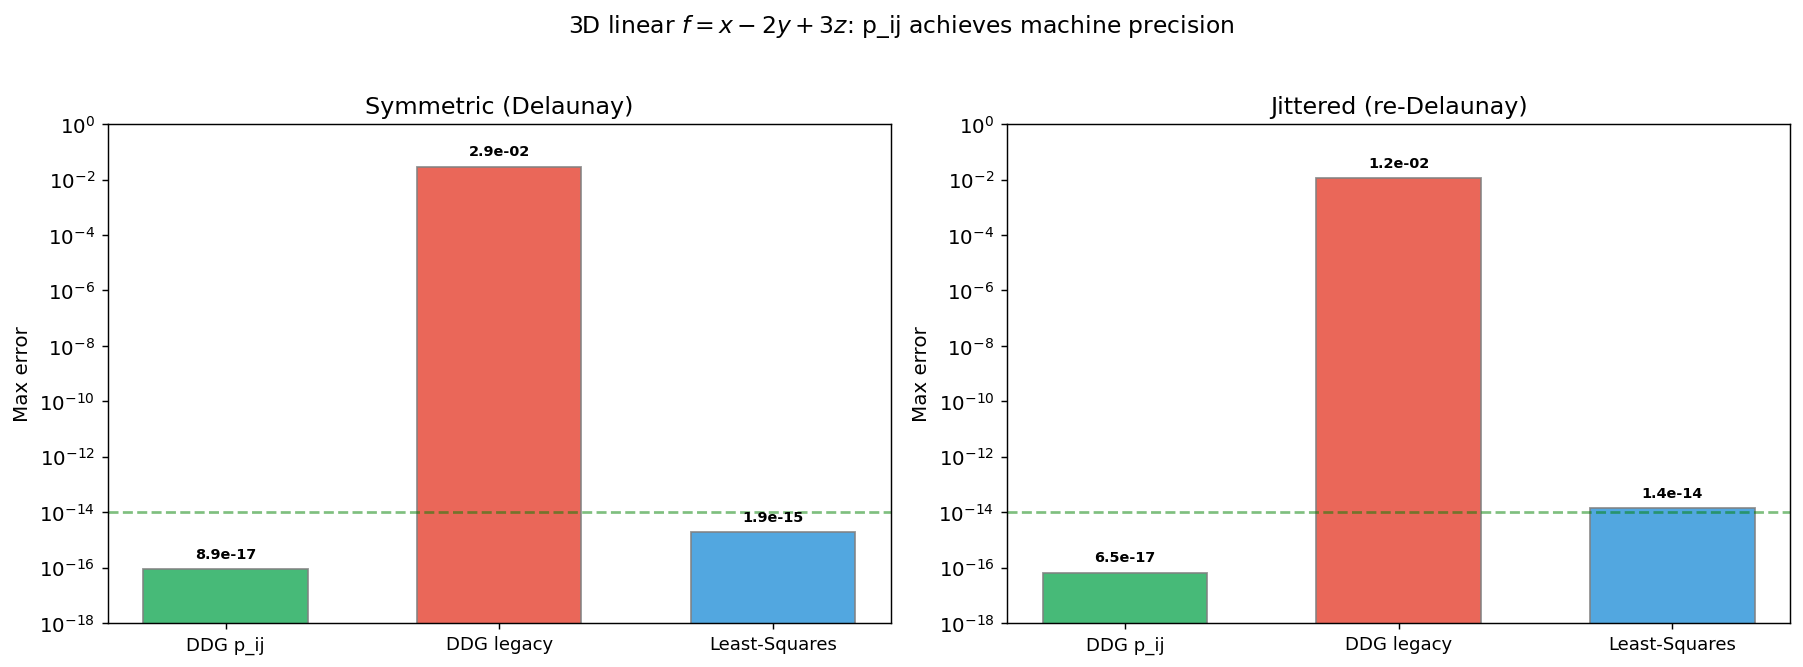

In [7]:
from scipy.spatial import Delaunay

def make_mesh_3d_jittered(n_refine=1, seed=42, jitter=0.05):
    HC = Complex(3, domain=[(0.0, 1.0)]*3)
    HC.triangulate()
    for _ in range(n_refine): HC.refine_all()
    bV = set()
    for v in HC.V:
        on_bnd = any(abs(v.x_a[d]) < 1e-14 or abs(v.x_a[d]-1.0) < 1e-14 for d in range(3))
        v.boundary = on_bnd
        if on_bnd: bV.add(v)
    rng = np.random.default_rng(seed)
    for v in HC.V:
        if v not in bV and v.nn:
            el = min(np.linalg.norm(v.x_a - vn.x_a) for vn in v.nn)
            off = rng.uniform(-jitter*el, jitter*el, size=3)
            HC.V.move(v, tuple(v.x_a[d]+off[d] for d in range(3)))
    verts = list(HC.V)
    for v in verts:
        for nb in list(v.nn): v.disconnect(nb)
    coords = np.array([v.x_a[:3] for v in verts])
    tri = Delaunay(coords)
    for simplex in tri.simplices:
        for i in range(len(simplex)):
            for j in range(i+1, len(simplex)):
                verts[simplex[i]].connect(verts[simplex[j]])
    compute_vd(HC, method='barycentric', cdist=1e-10)
    interior = [v for v in HC.V if v not in bV]
    return HC, bV, interior

def ls_gradient_3d(v, field_attr='f'):
    f_i = getattr(v, field_attr)
    nbs = list(v.nn)
    if len(nbs) < 3: return np.zeros(3)
    A = np.array([nb.x_a[:3] - v.x_a[:3] for nb in nbs])
    b = np.array([getattr(nb, field_attr) - f_i for nb in nbs])
    g, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return g

a = np.array([1.0, -2.0, 3.0])
f_lin = lambda x: x[0] - 2*x[1] + 3*x[2]
grad_exact = np.array([1.0, -2.0, 3.0])

methods = ['DDG p_ij', 'DDG legacy', 'Least-Squares']
bar_colors = ['#27ae60', '#e74c3c', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (mesh_label, mesh_fn) in zip(axes, [
    ('Symmetric (Delaunay)', lambda: make_mesh_3d(n_refine=1)),
    ('Jittered (re-Delaunay)', lambda: make_mesh_3d_jittered(n_refine=1)),
]):
    HC_t, bV_t, int_t = mesh_fn()
    for v in HC_t.V: v.f = f_lin(v.x_a[:3])

    errors = {m: [] for m in methods}
    for v in int_t:
        # p_ij
        Df = np.zeros(3)
        for nb in v.nn:
            Df += 0.5 * (nb.f - v.f) * _dual_area_vector_3d_p_ij(v, nb, HC_t)
        T = np.zeros((3,3))
        for nb in v.nn:
            T += 0.5 * np.outer(nb.x_a[:3]-v.x_a[:3], _dual_area_vector_3d_p_ij(v, nb, HC_t))
        vol = np.diag(T).mean()
        errors['DDG p_ij'].append(np.linalg.norm(Df - a*vol))

        # legacy
        Df_leg = np.zeros(3)
        for nb in v.nn:
            Df_leg += 0.5 * (nb.f - v.f) * _dual_area_vector_3d_e_star(v, nb, HC_t)
        errors['DDG legacy'].append(np.linalg.norm(Df_leg - a*vol))

        # LS
        g = ls_gradient_3d(v, 'f')
        errors['Least-Squares'].append(np.linalg.norm(g - grad_exact))

    x_pos = np.arange(len(methods))
    max_errs = [max(e) if max(e) > 0 else 1e-17 for e in errors.values()]
    bars = ax.bar(x_pos, max_errs, 0.6, color=bar_colors, alpha=0.85, edgecolor='gray')
    ax.set_yscale('log')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(methods, fontsize=10)
    ax.set_ylabel('Max error')
    ax.set_title(f'{mesh_label}')
    ax.axhline(1e-14, color='green', ls='--', alpha=0.5)
    ax.set_ylim(1e-18, 1e0)
    for bar, err in zip(bars, max_errs):
        ax.annotate(f'{err:.1e}', (bar.get_x()+bar.get_width()/2, err),
                    textcoords='offset points', xytext=(0,6), ha='center',
                    fontsize=8, weight='bold')

plt.suptitle('3D linear $f = x-2y+3z$: p_ij achieves machine precision',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Stress tensor validation: Poiseuille equilibrium

$u_x = \frac{G}{2\mu} z(D-z)$, $P = -Gx$.  At equilibrium $F_{\text{stress}} = 0$.

In [8]:
from ddgclib.operators.stress import stress_force, cache_dual_volumes

HC, bV, interior = make_mesh_3d(n_refine=1)
G, mu, D = 1.0, 1.0, 1.0
for v in HC.V:
    z = v.x_a[2]
    v.u = np.array([G/(2*mu)*z*(D-z), 0.0, 0.0])
    v.p = -G * v.x_a[0]
cache_dual_volumes(HC, dim=3)
for v in HC.V:
    v.m = 1.0 * v.dual_vol if v.dual_vol > 1e-30 else 1e-30

residuals = [np.linalg.norm(stress_force(v, dim=3, mu=mu, HC=HC))
             for v in interior]

print(f'3D Poiseuille Equilibrium (barycentric, p_ij area vectors)')
print(f'  Interior vertices: {len(interior)}')
print(f'  Max |F_stress|:    {max(residuals):.2e}')
print(f'  Mean |F_stress|:   {np.mean(residuals):.2e}')
status = 'EXACT' if max(residuals) < 1e-12 else 'residual'
print(f'  Status:            {status}')

3D Poiseuille Equilibrium (barycentric, p_ij area vectors)
  Interior vertices: 9
  Max |F_stress|:    2.29e-17
  Mean |F_stress|:   1.13e-17
  Status:            EXACT


## 7. Why the face barycenters matter

The 3D dual face polygon around a primal edge $(i, j)$ is formed by
the barycenters of the tetrahedra sharing that edge.  When the
tetrahedra are not coplanar (generic case), this polygon is
**non-planar**.  Different triangulations of a non-planar polygon give
different area vectors.

The DEC construction says the dual face boundary alternates:

$$\text{tet\_bary}_k \to \text{face\_bary}_{k,k+1} \to \text{tet\_bary}_{k+1} \to \cdots$$

where $\text{face\_bary}_{k,k+1} = \tfrac{1}{3}(\mathbf{x}_i + \mathbf{x}_j + \mathbf{x}_{k^\prime})$
is the barycenter of the triangular face shared by consecutive tets $T_k$ and $T_{k+1}$.

These intermediate vertices make each sub-triangle closer to planar,
and — crucially — they ensure the area vector sum satisfies:

$$\tfrac{1}{2}\sum_j \mathbf{d}_{ij} \otimes \mathbf{A}_{ij} = \text{Vol}_i \cdot \mathbf{I}$$

to **machine precision** on any mesh.